In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px
import numpy as np

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, crps_gp, crps_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.parameter_adaptation import parameter_adaptation, cross_validated_parameter_adaptation
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.util import run_inference_algorithm_with_burn_in, posterior_function_draws, predictive_moments

from non_parametric_pro.data.well_specified import (
    make_well_specified_instance,
    plot_well_specified_case
)

from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler
from scipy import stats

jax.config.update("jax_enable_x64", True)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


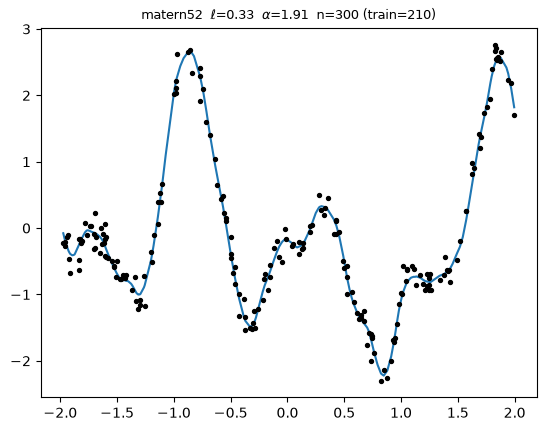

In [2]:
key = jr.PRNGKey(2421)
instance_keys = jr.split(key, num=20)
instance_key = instance_keys[3]

example = make_well_specified_instance(instance_key, n=300, train_fraction=0.7)

x_train, y_train = example.x_train, example.y_train
x_test, y_test = example.x_test, example.y_test

idx = np.argsort(x_test.squeeze())
x_test = x_test[idx]
y_test = y_test[idx]

fig, ax = plt.subplots()
plot_well_specified_case(ax, example)


In [3]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.RBF(lengthscale=0.3)

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
)

gp_latent_train_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_train_dist = gp_posterior.likelihood(gp_latent_train_dist)

gp_predictive_train_mean = gp_predictive_train_dist.mean
gp_predictive_train_std = jnp.sqrt(gp_predictive_train_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

Optimization terminated successfully.
         Current function value: -33.471632
         Iterations: 12
         Function evaluations: 19
         Gradient evaluations: 19
GP Train NLPD: -0.5587042747744831
GP Test NLPD: -0.4209699752694309


In [4]:
print("GP sigma", px.unwrap(gp_sigma))
print(px.unwrap(gp_kernel.lengthscale))
print(px.unwrap(gp_kernel.variance))

GP sigma 0.1464001883113597
0.16483417593353125
1.1880147179829208


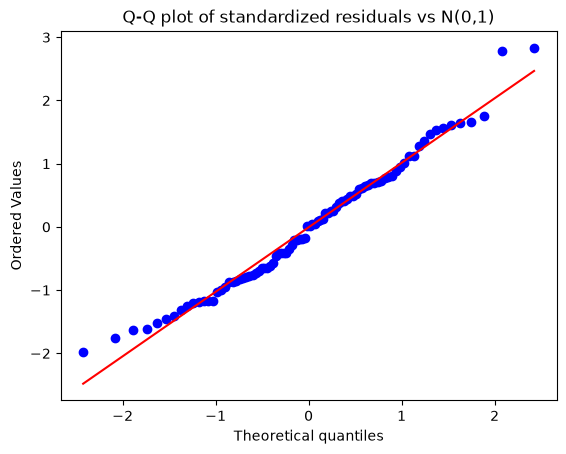

Shapiro-Wilk: 0.17101283227950564
Kolmogorov-Smirnov: 0.6479791747130854


In [5]:
residuals = (y_test.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

ks_stat, ks_pvalue = stats.kstest(residuals, "norm")

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals).pvalue)
print("Kolmogorov-Smirnov:", ks_pvalue)

In [41]:
num_particles = 32
sigma = gpx.parameters.SigmoidBounded(0.5, low=0.1, high=1.0)
lengthscale = gpx.parameters.SigmoidBounded(0.3, low=1.0e-3, high=1.0e3)
kernel = gpx.kernels.RBF(lengthscale=lengthscale)

k = kernel.gram(x_train).as_matrix()
basis = jnp.linalg.cholesky(k + 1e-6 * jnp.eye(k.shape[0]))

pro_params = ProParameters(
    y=y_train,
    basis=basis,
    step_size=0.0001,
    sigma=sigma,
    alpha=0.7,
)

adaptor = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_train=x_train,
    initial_kernel=kernel,
    warmup_steps=1000,
    sigma_adapt_steps=600,
    kernel_adapt_steps=350,
    objective_fn=pro_logdensity_fn,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(1e-2),
    progress_bar=True,
)

key, pos_key = jr.split(key)
initial_position = jr.normal(pos_key, (x_train.shape[0], num_particles))

adaptation_results, adaptation_info = adaptor.run(rng_key=key, position=initial_position, num_steps=30000)

# adaptation = cross_validated_parameter_adaptation(
#     ula,
#     pro_logdensity_fn,
#     pro_params,
#     x_full=x_train,
#     y_full=y_train,
#     initial_kernel=kernel,
#     num_folds=1,
#     val_fraction=0.1,
#     num_particles=num_particles,
#     num_steps=20000,
#     warmup_steps=1000,
#     sigma_adapt_steps=600,
#     kernel_adapt_steps=350,
#     objective_fn=pro_logdensity_fn,
#     sigma_optimizer=ox.adam(1e-1),
#     kernel_optimizer=ox.adam(0.01),
#     progress_bar=True,
#     rng_key=key
# ) 

adapted_sigma = px.unwrap(adaptation_results.parameters.sigma)
adapted_kernel = px.unwrap(
    jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
)
states = adaptation_results.state
adapted_params = adaptation_results.parameters

print("Adapted sigma:", adapted_sigma)

Running parameter adaptation


<div><progress max="30000" value="30000"></progress> 100.00% [30000/30000 00:00&lt;?]</div>

Adapted sigma: 0.10031930021283939


In [42]:
print(adapted_sigma)
print(adapted_kernel.lengthscale)
print(adapted_kernel.variance)

0.10031930021283939
0.17636647635410113
1.2675079933562245


In [48]:
states.position.shape

(210, 32)

In [50]:
particles = states.position

test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_train, adapted_params
)
print("PRO Train NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=adapted_params))

test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, adapted_params
)

print("PRO Test NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=adapted_params))
print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))
print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO Train NLPD: -0.5932196675611902
PRO Test NLPD: -0.28313947702488573
GP Train NLPD: -0.5587042747744831
GP Test NLPD: -0.4209699752694309


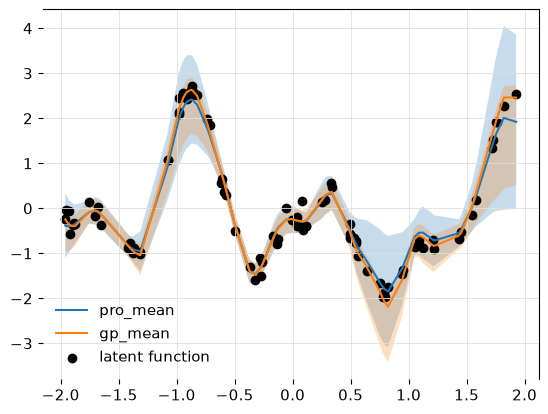

In [44]:
mean, std = predictive_moments(test_basis, particles, noise_std=adapted_sigma)

x_plot = x_test.squeeze()

plt.plot(x_plot, mean, label="pro_mean")
plt.plot(x_plot, gp_predictive_mean, label="gp_mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.fill_between(x_plot, gp_predictive_mean - 1.64 * std, gp_predictive_mean + 1.64 * gp_predictive_std, alpha=0.25)
plt.scatter(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function")
plt.legend()
plt.show()

In [45]:
test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, adapted_params
)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=100,
    jitter=adapted_params.jitter,
)

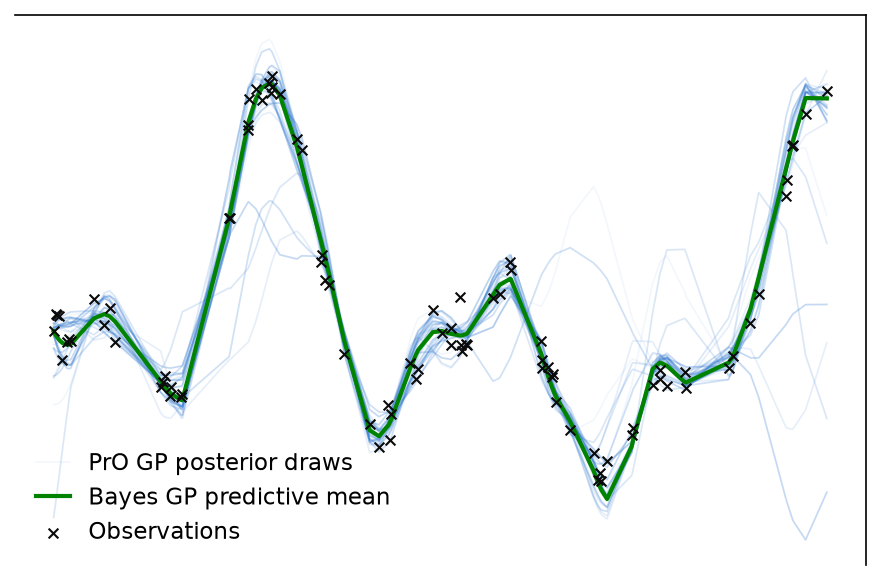

In [46]:

import numpy as np
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

draw_color = "#2a78d6"
mean_color = "#008300"
obs_color = "#0b0b0b"

order = np.argsort(x_test.squeeze())
x_sorted = x_test.squeeze()[order]
y_sorted = y_test.squeeze()[order]
mean_sorted = np.asarray(gp_predictive_mean).squeeze()[order]
draws_sorted = np.asarray(draws)[order]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(x_sorted, draws_sorted[:, 0], color=draw_color, alpha=0.06, linewidth=0.8,
        label="PrO GP posterior draws", rasterized=True)
ax.plot(x_sorted, draws_sorted[:, 1:], color=draw_color, alpha=0.06, linewidth=0.8,
        rasterized=True)
ax.plot(x_sorted, mean_sorted, color=mean_color, linewidth=2.0,
        label="Bayes GP predictive mean")
ax.scatter(x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0,
           label="Observations", zorder=5)

ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="best", handlelength=1.5)
fig.tight_layout()
plt.show()